In [4]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [5]:
hw_df = df[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]
print (hw_df.head())

   engine_displacement  horsepower  vehicle_weight  model_year  \
0                 2180       243.0            3870        2006   
1                 2390       272.0            4210        2008   
2                 2320       267.0            4240        1996   
3                 2130       258.0            4490        1989   
4                 2580       304.0            4510        1994   

   fuel_efficiency_mpg  
0                 31.9  
1                 31.3  
2                 27.5  
3                 28.5  
4                 31.0  


In [7]:
print(hw_df.isna().sum())
print('This hw.df shape is: ', hw_df.shape)

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64
This hw.df shape is:  (10000, 5)


In [20]:
print(hw_df.dtypes)


engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object


<Axes: xlabel='model_year', ylabel='Count'>

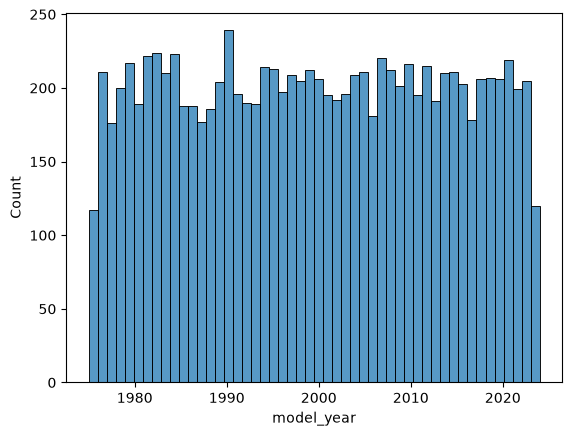

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.histplot(hw_df.model_year, bins=50)

In [25]:
Q2 = hw_df['horsepower'].median()
print (Q2)

254.0


In [37]:
import numpy as np

# 1. Get lengths
n = len(hw_df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# 2. Shuffle indices (Using Seed 42 first, or change to 9 for Q6)
np.random.seed(42) 
idx = np.arange(n)
np.random.shuffle(idx)

# 3. Split the data
df_train = hw_df.iloc[idx[:n_train]]
df_val = hw_df.iloc[idx[n_train:n_train + n_val]]
df_test = hw_df.iloc[idx[n_train + n_val:]]

print(df_train.head())
print(df_val.head())
print(df_test.head())

      engine_displacement  horsepower  vehicle_weight  model_year  \
6252                 1900       239.0            3790        2015   
4684                 2000       224.0            4380        1992   
1731                 2330       286.0            4090        2022   
4742                 2300         NaN            4150        1997   
4521                 2340       269.0            4400        2001   

      fuel_efficiency_mpg  
6252                 32.5  
4684                 29.1  
1731                 34.1  
4742                 30.6  
4521                 30.7  
      engine_displacement  horsepower  vehicle_weight  model_year  \
2480                 2240       265.0            3990        2004   
289                  2390       259.0            4770        2019   
6086                 2360       265.0            4320        2018   
3075                 2430       279.0            4430        2008   
8123                 2220       249.0            4030        1999   

  

In [84]:
features = df_train[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']]
y_train = df_train['fuel_efficiency_mpg']
x_raw = features.values
y = y_train.values
#add an intercept column for ML to figure out its num
intercept = np.ones((x_raw.shape[0],1))
x = np.hstack ((intercept,x_raw))
print (x[:5, :5])

[[   1. 1900.  239. 3790. 2015.]
 [   1. 2000.  224. 4380. 1992.]
 [   1. 2330.  286. 4090. 2022.]
 [   1. 2300.   nan 4150. 1997.]
 [   1. 2340.  269. 4400. 2001.]]


In [85]:
np.set_printoptions(suppress=True)

df_train['horsepower_with0'] = df_train['horsepower'].fillna(0)
#rebuild the x and y series

features = df_train[['engine_displacement',
'horsepower_with0',
'vehicle_weight',
'model_year']]
x_raw = features.values
y = y_train.values
intercept = np.ones((x_raw.shape[0],1))
x = np.hstack ((intercept,x_raw))
print (x[:5, :5])

[[   1. 1900.  239. 3790. 2015.]
 [   1. 2000.  224. 4380. 1992.]
 [   1. 2330.  286. 4090. 2022.]
 [   1. 2300.    0. 4150. 1997.]
 [   1. 2340.  269. 4400. 2001.]]


In [86]:
#Training linear regression: Normal equation
#.dot() is the command used to perform matrix multiplication.
np.set_printoptions(suppress=True)
x_transpose = x.T
xTx = x.T.dot(x)
x_inv = np.linalg.inv(xTx)
w = x_inv.dot(x_transpose).dot(y)

print(f"Calculated Intercept (Bias): {w[0]}")
print(f"engine_displacement weight:  {w[1]}")
print(f"horsepower weight:           {w[2]}")
print(f"vehicle_weight weight:       {w[3]}")
print(f"model_year weight:           {w[4]}")

test_mpg_with_0 = w[0] + (w[1] * 2240) + (w[2] * 265.0) + (w[3] * 3990) + (w[4] * 2004)
print(test_mpg)
#Actual target fuel_efficiency_mpg = 30.4

Calculated Intercept (Bias): -153.8849618823138
engine_displacement weight:  -0.0015150551951140694
horsepower weight:           -4.7402479448435154e-06
vehicle_weight weight:       -0.003954183967837818
model_year weight:           0.10214678495598814
31.645021335052633


In [87]:
#validate with 0 scenario

df_val['horsepower_with0'] = df['horsepower'].fillna(0)
features_val = df_val[['engine_displacement', 'horsepower_with0', 'vehicle_weight', 'model_year']]
x_val_raw = features_val.values
y_val = df_val['fuel_efficiency_mpg'].values
intercept_val = np.ones((x_val_raw.shape[0],1))
x_val = np.hstack((intercept_val, x_val_raw))
y_pred_with0 = x_val.dot(w)

np.set_printoptions(suppress=True)
print(y_pred_with0)
print ('Actual y validation sets are: ', y_val)

[31.64502134 29.86572978 31.58838899 ... 30.53133298 30.75085098
 31.62912778]
Actual y validation sets are:  [30.4 32.8 27.8 ... 30.6 31.  30.8]


In [88]:
#calculate RMSE in the with 0 scenario

rmse_with0 = np.sqrt(np.mean((y_pred_with0 - y_val)**2))
print('Original RMSE is: ', rmse_with0)
print('To replace NaN with 0, the rounded up RMSE result is: ', round(rmse_with0,3))


Original RMSE is:  2.2052931947534096
To replace NaN with 0, the rounded up RMSE result is:  2.205


In [89]:
np.set_printoptions(suppress=True)
print(df_train['horsepower'].mean())

df_train['horsepower_with_mean'] = df_train['horsepower'].fillna(df_train['horsepower'].mean())
#rebuild the x and y series

features = df_train[['engine_displacement',
'horsepower_with_mean',
'vehicle_weight',
'model_year']]
x_raw = features.values
y = y_train.values
x = np.hstack ((intercept,x_raw))
print (x[:5, :5])

254.46338337605272
[[   1.         1900.          239.         3790.         2015.        ]
 [   1.         2000.          224.         4380.         1992.        ]
 [   1.         2330.          286.         4090.         2022.        ]
 [   1.         2300.          254.46338338 4150.         1997.        ]
 [   1.         2340.          269.         4400.         2001.        ]]


In [90]:
#Training linear regression: Normal equation
#.dot() is the command used to perform matrix multiplication.
np.set_printoptions(suppress=True)
x_transpose = x.T
xTx = x.T.dot(x)
x_inv = np.linalg.inv(xTx)
w_mean = x_inv.dot(x_transpose).dot(y)

print(f"Calculated Intercept (Bias): {w_mean[0]}")
print(f"engine_displacement weight:  {w_mean[1]}")
print(f"horsepower weight:           {w_mean[2]}")
print(f"vehicle_weight weight:       {w_mean[3]}")
print(f"model_year weight:           {w_mean[4]}")

test_mpg_with_mean = w_mean[0] + (w_mean[1] * 2240) + (w_mean[2] * 265.0) + (w_mean[3] * 3990) + (w_mean[4] * 2004)
print(test_mpg)
#Actual target fuel_efficiency_mpg = 30.4

Calculated Intercept (Bias): -153.29645639114293
engine_displacement weight:  -0.0010238564080515408
horsepower weight:           -0.006486215481980608
vehicle_weight weight:       -0.003888276835077556
model_year weight:           0.10197896718245636
31.645021335052633


In [91]:
#validate with mean scenario

df_val['horsepower_with_mean'] = df['horsepower'].fillna(0)
features_val = df_val[['engine_displacement', 'horsepower_with_mean', 'vehicle_weight', 'model_year']]
x_val_raw = features_val.values
y_val = df_val['fuel_efficiency_mpg'].values
intercept_val = np.ones((x_val_raw.shape[0],1))
x_val = np.hstack((intercept_val, x_val_raw))
y_pred_with_mean = x_val.dot(w)

np.set_printoptions(suppress=True)
print(y_pred_with_mean)
print ('Actual y validation sets are: ', y_val)

[31.64502134 29.86572978 31.58838899 ... 30.53133298 30.75085098
 31.62912778]
Actual y validation sets are:  [30.4 32.8 27.8 ... 30.6 31.  30.8]


In [92]:
#calculate RMSE in the with mean scenario

rmse_with_mean = np.sqrt(np.mean((y_pred_with_mean - y_val)**2))

print('Original RMSE is: ', rmse_with_mean)
print('To replace NaN with mean results of "horsepower", the rounded up RMSE result is: ', round(rmse_with_mean,3))

Original RMSE is:  2.2052931947534096
To replace NaN with mean results of "horsepower", the rounded up RMSE result is:  2.205


In [93]:
#Answer to Q3, replace NaN with 0 is better

In [96]:
np.set_printoptions(suppress=True)

features = df_train[['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']]
df_train['horsepower_with0'] = df_train['horsepower'].fillna(0)
features = df_train[['engine_displacement',
'horsepower_with0',
'vehicle_weight',
'model_year']]

y_train = df_train['fuel_efficiency_mpg']
x_raw = features.values
y = y_train.values
#add an intercept column for ML to figure out its num
intercept = np.ones((x_raw.shape[0],1))
x = np.hstack ((intercept,x_raw))
print (x[:5, :5])

[[   1. 1900.  239. 3790. 2015.]
 [   1. 2000.  224. 4380. 1992.]
 [   1. 2330.  286. 4090. 2022.]
 [   1. 2300.    0. 4150. 1997.]
 [   1. 2340.  269. 4400. 2001.]]


In [108]:
xTx = x.T.dot(x)
xT_dot_y = x.T.dot(y)
xTx_inv = np.linalg.inv(xTx)
w = xTx_inv.dot(xT_dot_y)
print (w)

identity_matrix = np.eye(xTx.shape[0])
identity_matrix[0, 0] = 0
r_list = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_list:
    xTx_regularized = xTx + r * identity_matrix
    
    # Invert the regularized matrix: (X^T * X + r * I)^-1
    x_inv_reg = np.linalg.inv(xTx_regularized)
    
    # Calculate your regularized weights 
    w_reg = x_inv_reg.dot(xT_dot_y)
    
    # Make predictions on your validation set (x_val)
    y_pred_reg = x_val.dot(w_reg)
    
    # Calculate the exact RMSE score for this specific option
    rmse_reg = np.sqrt(np.mean((y_pred_reg - y_val) ** 2))
    
    # Display the final validation result for comparison
    print(f"Q4: Regularization Strength r = {r:<5} | Validation RMSE: {rmse_reg:.4f}")

[-153.88496188   -0.00151506   -0.00000474   -0.00395418    0.10214678]
Q4: Regularization Strength r = 0     | Validation RMSE: 2.2053
Q4: Regularization Strength r = 0.01  | Validation RMSE: 2.2053
Q4: Regularization Strength r = 0.1   | Validation RMSE: 2.2053
Q4: Regularization Strength r = 1     | Validation RMSE: 2.2053
Q4: Regularization Strength r = 5     | Validation RMSE: 2.2053
Q4: Regularization Strength r = 10    | Validation RMSE: 2.2053
Q4: Regularization Strength r = 100   | Validation RMSE: 2.2053


In [119]:
import numpy as np
# prep for Q5

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_scores = []
# 1. Get lengths
n = len(hw_df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for i in seeds:
    idx = np.arange(n)
    np.random.seed(i)
    np.random.shuffle(idx)

    # Split & prep the data
    df_train_q5 = hw_df.iloc[idx[:n_train]]
    df_val_q5 = hw_df.iloc[idx[n_train:n_train + n_val]]
    df_train_q5['horsepower_with0'] = df_train_q5['horsepower'].fillna(0)
    df_val_q5['horsepower_with0'] = df_val_q5['horsepower'].fillna(0)
    
    features_q5 = ['engine_displacement', 'horsepower_with0', 'vehicle_weight', 'model_year']
    y_train_q5 = df_train_q5['fuel_efficiency_mpg']
    x_raw_q5 = df_val_q5[features_q5].values
    x_val_q5 = np.hstack((np.ones((x_raw_q5.shape[0], 1)), x_raw_q5))
    y_val_q5 = df_val_q5['fuel_efficiency_mpg'].values
    x_transpose = x.T
    xTx = x.T.dot(x)
    x_inv = np.linalg.inv(xTx)
    w = x_inv.dot(x_transpose).dot(y)

    #validate
    y_pred_q5 = x_val_q5.dot(w)
    rmse = np.sqrt(np.mean((y_pred_q5 - y_val_q5) ** 2))
    rmse_scores.append(rmse)
    print(f"Seed {i} | Validation RMSE Score: {rmse:.4f}")

q5_std = np.std(rmse_scores)

print('standard deviation of all the scores is: ', round(q5_std,3))


Seed 0 | Validation RMSE Score: 2.2385
Seed 1 | Validation RMSE Score: 2.2034
Seed 2 | Validation RMSE Score: 2.1633
Seed 3 | Validation RMSE Score: 2.2031
Seed 4 | Validation RMSE Score: 2.1984
Seed 5 | Validation RMSE Score: 2.2443
Seed 6 | Validation RMSE Score: 2.2688
Seed 7 | Validation RMSE Score: 2.1911
Seed 8 | Validation RMSE Score: 2.2154
Seed 9 | Validation RMSE Score: 2.2066
standard deviation of all the scores is:  0.029


In [124]:
# prep for Q6
# 1. Get lengths
n = len(hw_df)
n_test = int(n * 0.2)
n_train = n - n_test

# 2. Shuffle indices (Using 9 for Q6)
np.random.seed(9) 
idx = np.arange(n)
np.random.shuffle(idx)

# 3. Split the data
df_train = hw_df.iloc[idx[:n_train]]
df_test = hw_df.iloc[idx[n_train:]]

print(df_train.head())
print(df_test.head())

np.set_printoptions(suppress=True)

df_train['horsepower_with0'] = df_train['horsepower'].fillna(0)
features = df_train[['engine_displacement',
'horsepower_with0',
'vehicle_weight',
'model_year']]

y_train = df_train['fuel_efficiency_mpg']
x_raw = features.values
y = y_train.values
#add an intercept column for ML to figure out its num
intercept = np.ones((x_raw.shape[0],1))
x = np.hstack ((intercept,x_raw))
print (x[:5, :5])

xTx = x.T.dot(x)
i_matrix = np.eye(xTx.shape[0])
i_matrix [0, 0] = 0

xT_dot_y = x.T.dot(y)
xTx_inv = np.linalg.inv((xTx + 0.001 * i_matrix))
w = xTx_inv.dot(xT_dot_y)
print (w)

      engine_displacement  horsepower  vehicle_weight  model_year  \
3644                 2320       246.0            4100        2014   
9184                 2230       252.0            4250        1998   
520                  2700       276.0            4490        2008   
5685                 2220       269.0            4060        2004   
2401                 2370         NaN            4690        1979   

      fuel_efficiency_mpg  
3644                 32.5  
9184                 33.2  
520                  32.4  
5685                 29.9  
2401                 26.4  
      engine_displacement  horsepower  vehicle_weight  model_year  \
5463                 2100       258.0            4060        2011   
9878                 2160       223.0            4130        2011   
8503                 2190         NaN            4030        1975   
2571                 2320       257.0            4640        1997   
6851                 2330       235.0            4130        1988   

  

In [126]:
df_test['horsepower_with0'] = df_test['horsepower'].fillna(0)
features_test = df_test[['engine_displacement', 'horsepower_with0', 'vehicle_weight', 'model_year']]

# 2. Extract the test numerical matrices
x_test_raw = features_test.values
y_test = df_test['fuel_efficiency_mpg'].values

# 3. Add the intercept column of 1s to match 'w'
intercept_test = np.ones((x_test_raw.shape[0], 1))
x_test = np.hstack((intercept_test, x_test_raw))

# 4. Make predictions on your test data
y_pred_test = x_test.dot(w)

# 5. Calculate the final Test RMSE
rmse_test = np.sqrt(np.mean((y_pred_test - y_test) ** 2))

print(f"\nFinal RMSE: {rmse_test:.4f}")


Final RMSE: 2.2358
